In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Example: hours studied vs pass(1)/fail(0)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 1, 0, 1, 1, 1, 1])

df = pd.DataFrame({'Hours': X.flatten(), 'Pass': y})
df

,Hours,Pass
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,0
6,7,1
7,8,1
8,9,1
9,10,1


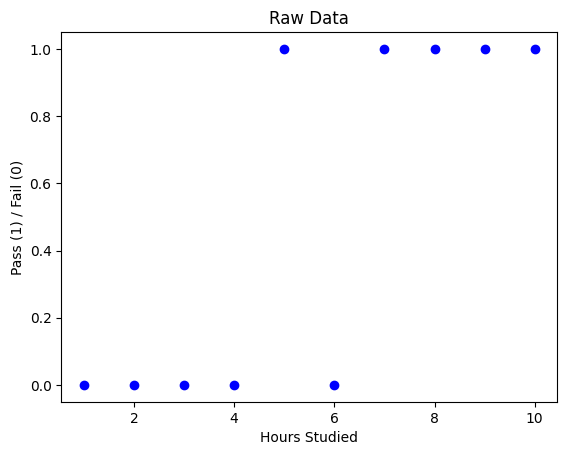

In [ ]:
plt.scatter(X, y, color='blue')
plt.xlabel('Hours Studied')
plt.ylabel('Pass (1) / Fail (0)')
plt.title('Raw Data')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 8
Test size: 2


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: [0.83147845]
Intercept: [-4.57320109]


In [ ]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

,Actual,Predicted
0,1,1
1,0,0


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[1 0]
 [0 1]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



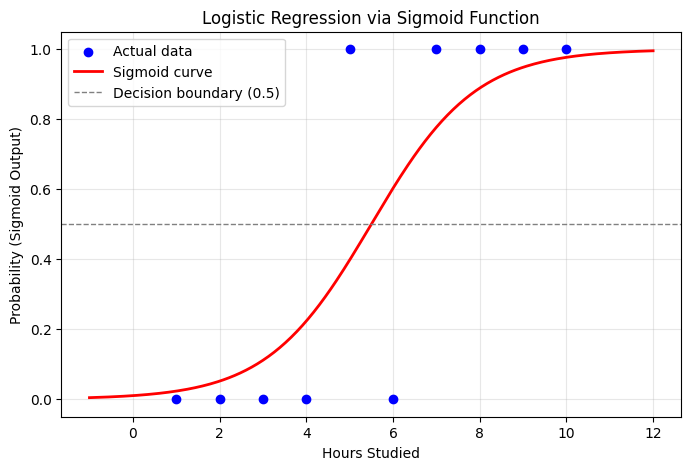

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Get model's learned parameters
m = model.coef_[0][0]
c = model.intercept_[0]

# Generate smooth range of X values for plotting
X_range = np.linspace(X.min() - 2, X.max() + 2, 300)

# Compute z (linear part) and pass through sigmoid
z = m * X_range + c
y_sigmoid = sigmoid(z)

plt.figure(figsize=(8, 5))

# Actual data points
plt.scatter(X, y, color='blue', label='Actual data', zorder=3)

# Sigmoid curve
plt.plot(X_range, y_sigmoid, color='red', linewidth=2, label='Sigmoid curve')

# Decision boundary
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Decision boundary (0.5)')

plt.xlabel('Hours Studied')
plt.ylabel('Probability (Sigmoid Output)')
plt.title('Logistic Regression via Sigmoid Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()